## Importing Libraries 

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error

## Loading Dataset

In [32]:
df = pd.read_csv(r'database.csv')
df

,Flight Number,Launch Date,Launch Time,Launch Site,Vehicle Type,Payload Name,Payload Type,Payload Mass (kg),Payload Orbit,Customer Name,Customer Type,Customer Country,Mission Outcome,Failure Reason,Landing Type,Landing Outcome
0,F1-1,24 March 2006,22:30,Marshall Islands,Falcon 1,FalconSAT-2,Research Satellite,19.5,NaN,DARPA,Government,United States,Failure,Engine Fire During Launch,NaN,NaN
1,F1-2,21 March 2007,01:10,Marshall Islands,Falcon 1,DemoSat,NaN,NaN,NaN,DARPA,Government,United States,Failure,Engine Shutdown During Launch,NaN,NaN
2,F1-3,3 August 2008,03:34,Marshall Islands,Falcon 1,Trailblazer,Communication Satellite,NaN,NaN,ORS,Government,United States,Failure,Collision During Launch,NaN,NaN
3,F1-3,3 August 2008,03:34,Marshall Islands,Falcon 1,"PRESat, NanoSail-D",Research Satellites,8.0,NaN,NASA,Government,United States,Failure,Collision During Launch,NaN,NaN
4,F1-3,3 August 2008,03:34,Marshall Islands,Falcon 1,Explorers,Human Remains,NaN,NaN,Celestis,Business,United States,Failure,Collision During Launch,NaN,NaN
5,F1-4,28 September 2008,23:15,Marshall Islands,Falcon 1,RatSat (DemoSat),NaN,165.0,Low Earth Orbit,NaN,NaN,NaN,Success,NaN,NaN,NaN
6,F1-5,14 July 2009,03:35,Marshall Islands,Falcon 1,RazakSAT,Weather Satellite,180.0,Low Earth Orbit,ATSB,Government,Malaysia,Success,NaN,NaN,NaN
7,F9-1,4 June 2010,18:45,Cape Canaveral AFS LC-40,Falcon 9 (v1.0),Dragon Spacecraft Qualification Unit,NaN,NaN,Low Earth Orbit,NaN,NaN,NaN,Success,NaN,Parachute,Failure
8,F9-2,8 December 2010,15:43,Cape Canaveral AFS LC-40,Falcon 9 (v1.0),SpaceX CRS (Dragon C1),Space Station Supplies,NaN,Low Earth Orbit,NASA,Government,United States,Success,NaN,Parachute,Failure
9,F9-3,22 May 2012,07:44,Cape Canaveral AFS LC-40,Falcon 9 (v1.0),SpaceX CRS (Dragon C2+),Space Station Supplies,NaN,Low Earth Orbit,NASA,Government,United States,Success,NaN,NaN,NaN


## EDA

In [33]:
df.head()

,Flight Number,Launch Date,Launch Time,Launch Site,Vehicle Type,Payload Name,Payload Type,Payload Mass (kg),Payload Orbit,Customer Name,Customer Type,Customer Country,Mission Outcome,Failure Reason,Landing Type,Landing Outcome
0,F1-1,24 March 2006,22:30,Marshall Islands,Falcon 1,FalconSAT-2,Research Satellite,19.5,NaN,DARPA,Government,United States,Failure,Engine Fire During Launch,NaN,NaN
1,F1-2,21 March 2007,01:10,Marshall Islands,Falcon 1,DemoSat,NaN,NaN,NaN,DARPA,Government,United States,Failure,Engine Shutdown During Launch,NaN,NaN
2,F1-3,3 August 2008,03:34,Marshall Islands,Falcon 1,Trailblazer,Communication Satellite,NaN,NaN,ORS,Government,United States,Failure,Collision During Launch,NaN,NaN
3,F1-3,3 August 2008,03:34,Marshall Islands,Falcon 1,"PRESat, NanoSail-D",Research Satellites,8.0,NaN,NASA,Government,United States,Failure,Collision During Launch,NaN,NaN
4,F1-3,3 August 2008,03:34,Marshall Islands,Falcon 1,Explorers,Human Remains,NaN,NaN,Celestis,Business,United States,Failure,Collision During Launch,NaN,NaN


In [34]:
df.shape

(41, 16)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Flight Number      41 non-null     object 
 1   Launch Date        41 non-null     object 
 2   Launch Time        41 non-null     object 
 3   Launch Site        41 non-null     object 
 4   Vehicle Type       41 non-null     object 
 5   Payload Name       41 non-null     object 
 6   Payload Type       38 non-null     object 
 7   Payload Mass (kg)  33 non-null     float64
 8   Payload Orbit      36 non-null     object 
 9   Customer Name      39 non-null     object 
 10  Customer Type      39 non-null     object 
 11  Customer Country   39 non-null     object 
 12  Mission Outcome    41 non-null     object 
 13  Failure Reason     8 non-null      object 
 14  Landing Type       21 non-null     object 
 15  Landing Outcome    21 non-null     object 
dtypes: float64(1), object(15)
me

In [36]:
df.describe()

,Payload Mass (kg)
count,33.000000
mean,2739.772727
std,2131.502973
min,8.000000
25%,570.000000
50%,2490.000000
75%,4159.000000
max,9600.000000


In [37]:
df.isnull().sum()

Flight Number         0
Launch Date           0
Launch Time           0
Launch Site           0
Vehicle Type          0
Payload Name          0
Payload Type          3
Payload Mass (kg)     8
Payload Orbit         5
Customer Name         2
Customer Type         2
Customer Country      2
Mission Outcome       0
Failure Reason       33
Landing Type         20
Landing Outcome      20
dtype: int64

## Data Cleaning 

In [38]:
df_clean = df.dropna(subset=['Mission Outcome', 'Launch Site'])
df_clean['Year'] = pd.to_datetime(df_clean['Launch Date']).dt.year
print("After cleaning records:", len(df_clean))

After cleaning records: 41


## Mission Outcome Distribution

In [39]:
outcome_counts = df_clean['Mission Outcome'].value_counts()
outcome_counts

Mission Outcome
Success    33
Failure     8
Name: count, dtype: int64

## Launch Site-wise Mission Count

In [40]:
site_counts = df_clean['Launch Site'].value_counts()
site_counts.head(10)

Launch Site
Cape Canaveral AFS LC-40       30
Marshall Islands                7
Vandenberg AFB SLC-4E           3
Kennedy Space Center LC-39A     1
Name: count, dtype: int64

## Vehicle Type Distribution

In [41]:
vehicle_counts = df_clean['Vehicle Type'].value_counts()
vehicle_counts

Vehicle Type
Falcon 9 (v1.1)                16
Falcon 9 Full Thrust (v1.2)    12
Falcon 1                        7
Falcon 9 (v1.0)                 6
Name: count, dtype: int64

## Mission Success Rate by Year

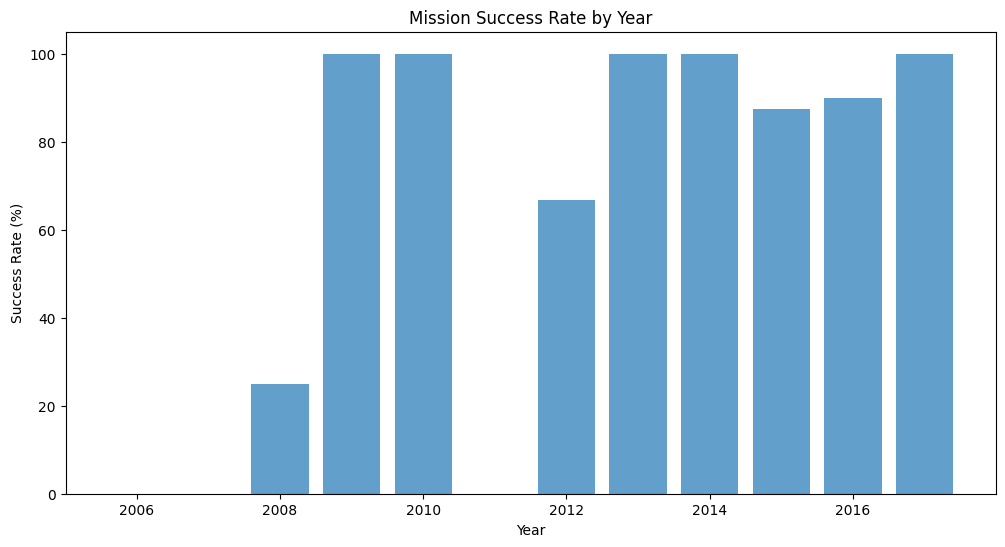

In [42]:
yearly_success = df_clean.groupby('Year')['Mission Outcome'].apply(
    lambda x: (x == 'Success').sum() / len(x) * 100
)
yearly_launches = df_clean.groupby('Year').size()
plt.figure(figsize=(12, 6))
plt.bar(yearly_success.index, yearly_success.values, alpha=0.7)
plt.xlabel('Year')
plt.ylabel('Success Rate (%)')
plt.title('Mission Success Rate by Year')
plt.ylim(0, 105)
plt.show()

## Launches Over Time

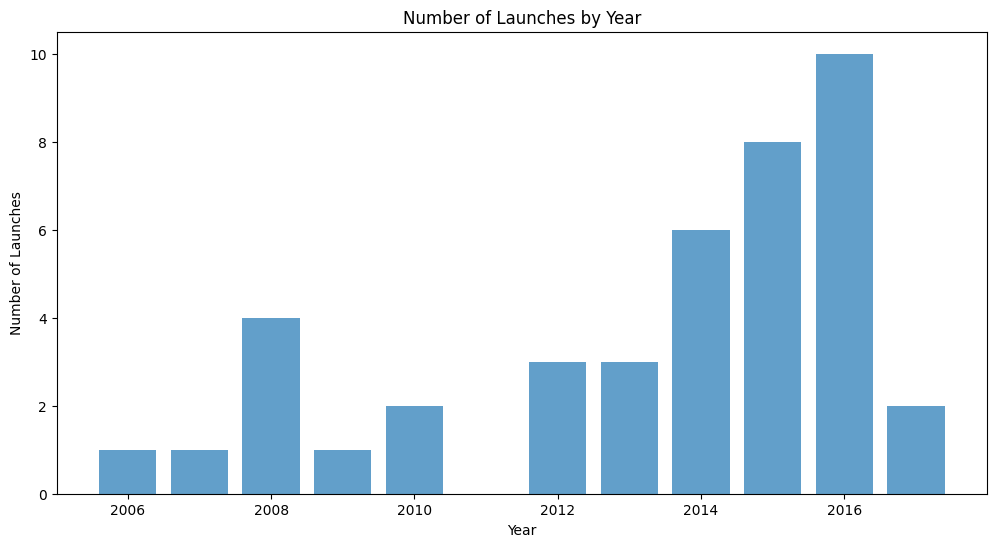

In [43]:
plt.figure(figsize=(12, 6))
plt.bar(yearly_launches.index, yearly_launches.values, alpha=0.7)
plt.xlabel('Year')
plt.ylabel('Number of Launches')
plt.title('Number of Launches by Year')
plt.show()

## Encode Categorical Columns

In [44]:
le = LabelEncoder()
df_clean['Launch_Site_Encoded'] = le.fit_transform(df_clean['Launch Site'])
df_clean['Vehicle_Type_Encoded'] = le.fit_transform(df_clean['Vehicle Type'])
df_clean['Outcome'] = (df_clean['Mission Outcome'] == 'Success').astype(int)
df_clean[['Launch Site', 'Launch_Site_Encoded', 'Vehicle Type', 'Vehicle_Type_Encoded', 'Outcome']].head()

,Launch Site,Launch_Site_Encoded,Vehicle Type,Vehicle_Type_Encoded,Outcome
0,Marshall Islands,2,Falcon 1,0,0
1,Marshall Islands,2,Falcon 1,0,0
2,Marshall Islands,2,Falcon 1,0,0
3,Marshall Islands,2,Falcon 1,0,0
4,Marshall Islands,2,Falcon 1,0,0


## Statistical Operations

In [45]:
arr = np.array(df_clean['Outcome'])
print("Mean (Success Rate):", np.mean(arr) * 100)
print("Total Success:", np.sum(arr))
print("Total Failures:", len(arr) - np.sum(arr))

Mean (Success Rate): 80.48780487804879
Total Success: 33
Total Failures: 8


##  Logistic Regression Classification

In [46]:
X = df_clean[['Year', 'Launch_Site_Encoded', 'Vehicle_Type_Encoded']]
y = df_clean['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred, target_names=['Failure', 'Success']))

Accuracy: 0.7777777777777778

Confusion Matrix:
 [[1 0]
 [2 6]]

Classification Report:
               precision    recall  f1-score   support

     Failure       0.33      1.00      0.50         1
     Success       1.00      0.75      0.86         8

    accuracy                           0.78         9
   macro avg       0.67      0.88      0.68         9
weighted avg       0.93      0.78      0.82         9



## Linear Regression - Predict Payload Mass

In [47]:
df_reg = df_clean[df_clean['Payload Mass (kg)'].notna()]
X = df_reg[['Year']]
y = df_reg['Payload Mass (kg)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

MSE: 6702381.631836756
RMSE: 2588.895832558111


## KMeans Clustering

In [48]:
X_cluster = df_clean[['Year', 'Launch_Site_Encoded', 'Vehicle_Type_Encoded']]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['Cluster'] = kmeans.fit_predict(X_cluster)

print(df_clean[['Year', 'Launch Site', 'Vehicle Type', 'Cluster']].head())

   Year       Launch Site Vehicle Type  Cluster
0  2006  Marshall Islands     Falcon 1        1
1  2007  Marshall Islands     Falcon 1        1
2  2008  Marshall Islands     Falcon 1        1
3  2008  Marshall Islands     Falcon 1        1
4  2008  Marshall Islands     Falcon 1        1


## Cluster Distribution

In [49]:
print("Cluster Distribution:")
print(df_clean['Cluster'].value_counts())
print("\nCluster Centers:")
print(pd.DataFrame(kmeans.cluster_centers_, columns=['Year', 'Launch_Site_Encoded', 'Vehicle_Type_Encoded']))

Cluster Distribution:
Cluster
0    20
2    12
1     9
Name: count, dtype: int64

Cluster Centers:
          Year  Launch_Site_Encoded  Vehicle_Type_Encoded
0  2015.700000             0.350000              2.600000
1  2008.222222             1.555556              0.222222
2  2013.250000             0.250000              1.666667


## Cluster Visualization

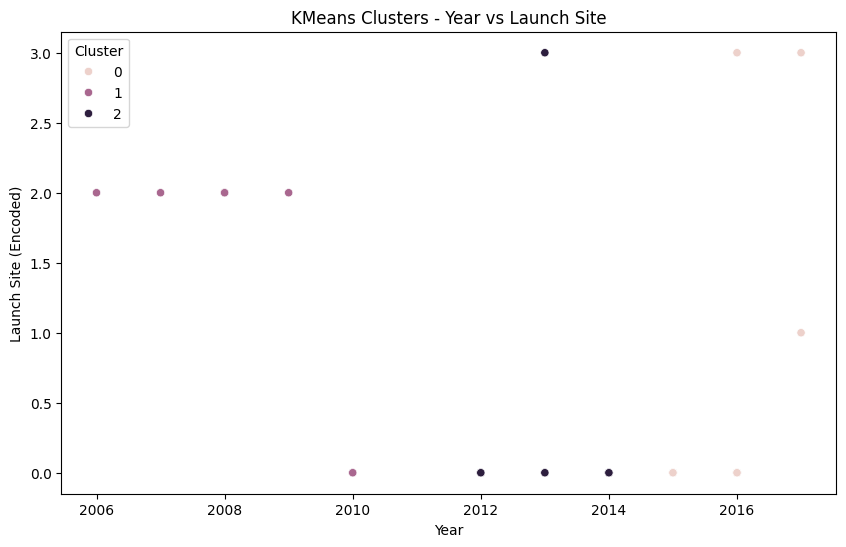

In [50]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_clean['Year'], y=df_clean['Launch_Site_Encoded'], hue=df_clean['Cluster'])
plt.title('KMeans Clusters - Year vs Launch Site')
plt.xlabel('Year')
plt.ylabel('Launch Site (Encoded)')
plt.show()

## Random Forest Classifier

In [51]:
X = df_clean[['Year', 'Launch_Site_Encoded', 'Vehicle_Type_Encoded']]
y = df_clean['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("\nFeature Importance:")
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print(importance)

Accuracy: 1.0

Feature Importance:
                Feature  Importance
0                  Year    0.608703
2  Vehicle_Type_Encoded    0.210804
1   Launch_Site_Encoded    0.180493


## Business Insights

In [52]:
best_year = yearly_launches.idxmax()
print("Year with Most Launches:", best_year, "(", yearly_launches.max(), "launches)")

best_success_year = yearly_success.idxmax()
print("Year with Best Success Rate:", best_success_year, "(", yearly_success.max(), "%)")

vehicle_success = df_clean.groupby('Vehicle Type')['Outcome'].mean().sort_values(ascending=False)
print("\nVehicle Type Success Rates:")
print(vehicle_success.head())

Year with Most Launches: 2016 ( 10 launches)
Year with Best Success Rate: 2009 ( 100.0 %)

Vehicle Type Success Rates:
Vehicle Type
Falcon 9 (v1.1)                0.937500
Falcon 9 Full Thrust (v1.2)    0.916667
Falcon 9 (v1.0)                0.833333
Falcon 1                       0.285714
Name: Outcome, dtype: float64


## Landing Outcome Distribution

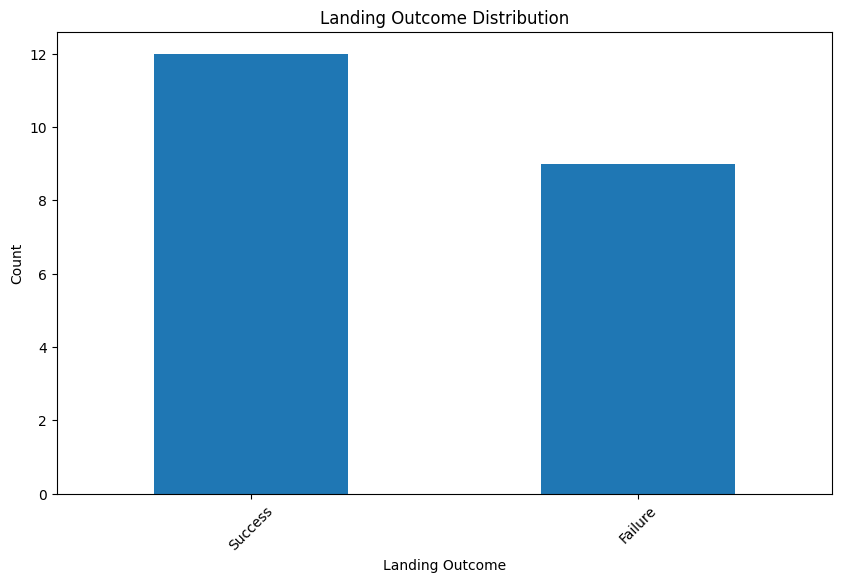

In [ ]:
landing_counts = df_clean['Landing Outcome'].value_counts()
landing_counts = landing_counts[landing_counts.index != '']

plt.figure(figsize=(10,6))
landing_counts.plot(kind='bar')
plt.xlabel('Landing Outcome')
plt.ylabel('Count')
plt.title('Landing Outcome Distribution')
plt.xticks(rotation=45)
plt.show()

## Mission Outcome by Vehicle Type

<Figure size 1200x600 with 0 Axes>

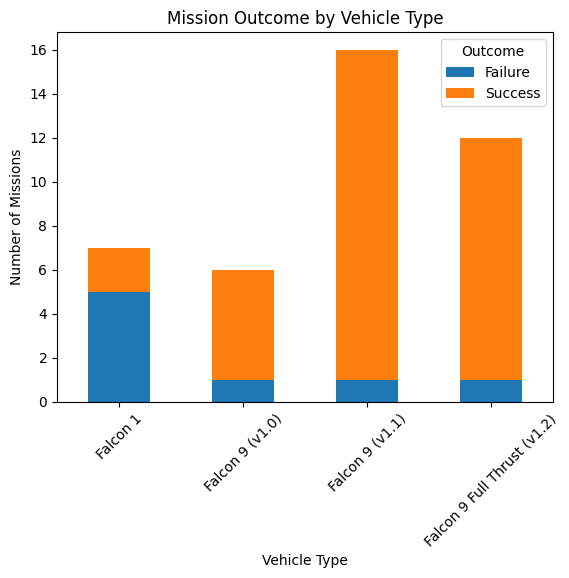

In [54]:
plt.figure(figsize=(12, 6))
outcome_by_vehicle = pd.crosstab(df_clean['Vehicle Type'], df_clean['Mission Outcome'])
outcome_by_vehicle.plot(kind='bar', stacked=True)
plt.xlabel('Vehicle Type')
plt.ylabel('Number of Missions')
plt.title('Mission Outcome by Vehicle Type')
plt.xticks(rotation=45)
plt.legend(title='Outcome')
plt.show()

## Predict Future Missions

In [55]:
site_map = (
    df_clean[['Launch Site', 'Launch_Site_Encoded']]
    .drop_duplicates()
    .set_index('Launch Site')['Launch_Site_Encoded']
    .to_dict()
)
vehicle_map = (
    df_clean[['Vehicle Type', 'Vehicle_Type_Encoded']]
    .drop_duplicates()
    .set_index('Vehicle Type')['Vehicle_Type_Encoded']
    .to_dict()
)
future_years = pd.DataFrame({
    'Year': [2025, 2026, 2027],
    'Launch_Site_Encoded': [site_map['Cape Canaveral AFS LC-40']] * 3,
    'Vehicle_Type_Encoded': [vehicle_map['Falcon 9 Full Thrust (v1.2)']] * 3
})
future_prob = model.predict_proba(future_years)
print("Future Mission Success Predictions:")
for i, year in enumerate([2025, 2026, 2027]):
    print(f"{year}: {future_prob[i][1]*100:.1f}% chance of success")

Future Mission Success Predictions:
2025: 88.0% chance of success
2026: 88.0% chance of success
2027: 88.0% chance of success
